# 1. loop vs. vectorised

In [2]:
import numpy as np

def entropy(y):
    _, counts = np.unique(y, return_counts=True)  
    probs = counts / counts.sum()                 
    return -np.sum(probs * np.log2(probs + 1e-9)) 

def impurity_gain( y, y_left, y_right):
    return entropy(y) - (len(y_left)/len(y))*entropy(y_left) - (len(y_right)/len(y))*entropy(y_right)
    
def best_split( X, y):
    best_gain = -1                
    best_feat = None             
    best_thresh = None           

    features = np.arange(X.shape[1])
    
    for feat in features:                    
        thresholds = np.unique(X[:, feat])             
        for thresh in thresholds:                      

            left = y[X[:, feat] <= thresh]             
            right = y[X[:, feat] > thresh]            

            if len(left) == 0 or len(right) == 0:     
                continue
            
            gain = impurity_gain(y, left, right)

            if gain > best_gain:                       
                best_gain = gain
                best_feat = feat
                best_thresh = thresh

    return best_feat, best_thresh

def best_split_vectorised(X, y):
    best_gain = -1                
    best_feat = None             
    best_thresh = None           

    features = np.arange(X.shape[1])
    
    
    for feat in features:
        feat_sort = np.argsort(X[:,feat])
        X_sorted = X[feat_sort,feat]
        y_sorted = y[feat_sort]
        
        thresholds = np.where(X_sorted[:-1] != X_sorted[1:])[0]
        
        for i in thresholds:
            left = y_sorted[:i+1]
            right = y_sorted[i+1:]
            
            gain = impurity_gain(y, left, right)

            if gain > best_gain:
                best_gain   = gain
                best_feat   = feat
                best_thresh = (X_sorted[i] + X_sorted[i + 1]) / 2.0

    return best_feat, best_thresh

In [15]:
import time
import tracemalloc

size = [100, 500, 1000, 5000, 10000]
times = 5
time_origin = []
time_vectorised = []

memory_origin = []
memory_vectorised = []

for i in range(times):

    X = np.random.randint(0, 10, size=(size[i], 10))
    y = np.random.randint(0, 1, size=(size[i],1))

    tracemalloc.start()
    start_origin = time.time()

    best_split(X, y)

    end_origin = time.time()
    _, peak_origin = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    tracemalloc.start()
    start_vectorised = time.time()

    best_split_vectorised(X, y)

    end_vectorised = time.time()
    _, peak_vectorised = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    time_origin.append(round((end_origin - start_origin), 4))
    time_vectorised.append(round((end_vectorised - start_vectorised), 4))

    memory_origin.append(round(peak_origin / 1024 / 1024, 4))
    memory_vectorised.append(round(peak_vectorised / 1024 / 1024, 4))
    
    

for i in range(times):
    print(f'{'#'*60}')
    print(f'Size:{size[i]}')
    print('Origin performance:')
    print(f'Time(seconds):{time_origin[i]}, Memory(MB):{memory_origin[i]}')

    print('\nVecorised performance:')
    print(f'Time(seconds):{time_vectorised[i]}, Memory(MB):{memory_vectorised[i]}')

############################################################
Size:100
Origin performance:
Time(seconds):0.0805, Memory(MB):0.0058

Vecorised performance:
Time(seconds):0.0765, Memory(MB):0.0103
############################################################
Size:500
Origin performance:
Time(seconds):0.0766, Memory(MB):0.0119

Vecorised performance:
Time(seconds):0.1017, Memory(MB):0.021
############################################################
Size:1000
Origin performance:
Time(seconds):0.107, Memory(MB):0.02

Vecorised performance:
Time(seconds):0.0763, Memory(MB):0.0336
############################################################
Size:5000
Origin performance:
Time(seconds):0.1221, Memory(MB):0.0848

Vecorised performance:
Time(seconds):0.0768, Memory(MB):0.1402
############################################################
Size:10000
Origin performance:
Time(seconds):0.1392, Memory(MB):0.1659

Vecorised performance:
Time(seconds):0.0916, Memory(MB):0.2737


# 2. Visualisation

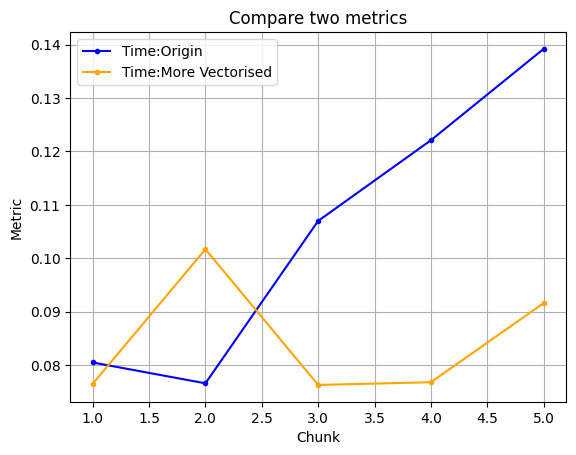

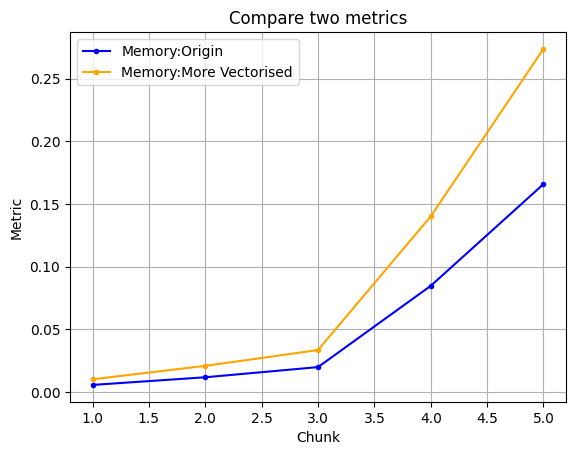

In [16]:
import sys
sys.path.append("..")

from numcompute_stream.visualise import  compare_models

compare_models(time_origin, time_vectorised, labels=['Time:Origin','Time:More Vectorised'])
compare_models(memory_origin, memory_vectorised, labels=['Memory:Origin','Memory:More Vectorised'])